In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D

C:\Users\myrit\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [18]:
from tensorflow.keras import layers, models

In [13]:
import matplotlib.pyplot as plt

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
model = tf.keras.models.load_model('face_mask_model.h5')

In [6]:
import ipywidgets as widgets
import cv2
import numpy as np
import PIL as Image

In [7]:
upload = widgets.FileUpload(accept = 'image/*', mulitle = False)
display(upload)

FileUpload(value=(), accept='image/*', description='Upload')

In [36]:
content = upload.value[0]['content']

In [37]:
nparr = np.frombuffer(content, np.uint8)
image = cv2.imdecode(nparr, cv2.IMREAD_COLOR)  # BGR
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # RGB for matplotlib

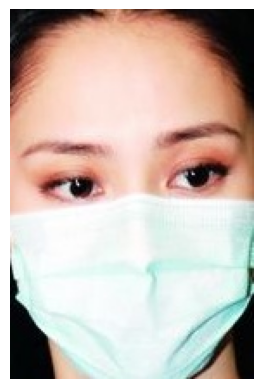

In [38]:
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [39]:
img_resized = cv2.resize(image_rgb, (128, 128))
img_array = np.array(img_resized, dtype = 'float32')

In [40]:
nomralization_layer = layers.Rescaling(1./255)
img_normalized = nomralization_layer(img_array)

In [41]:
img_input = np.expand_dims(img_normalized, axis=0)# Add batch dimesion -> (1, hight, weight, 3)

In [42]:
img_input.shape

(1, 128, 128, 3)

In [43]:
y_pred = model.predict(img_input)

1/1 [==============================] - 0s 220ms/step


In [44]:
y_pred

array([[0.94500566, 0.05499439]], dtype=float32)

Mask Detected 0.94500566


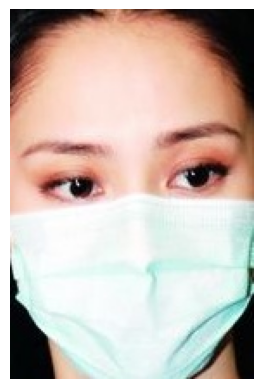

In [45]:
if y_pred[0][0]>y_pred[0][1]:
    print("Mask Detected", y_pred[0][0])
else:
    print("No Mask Detected", y_pred[0][1])
    
plt.imshow(image_rgb)
plt.axis('off')
plt.show()